# Customer Churn Prediction Analysis

This project analyzes customer churn patterns in a telecom dataset and builds machine learning models to predict whether a customer is likely to leave the service.

The project includes:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Machine learning model training
- Model evaluation and interpretation

The objective is to help telecom companies identify at-risk customers and improve retention strategies.

# 1. Import Libraries

In [11]:
# Data Handling libraries 
import pandas as pd
import numpy as np

# Data Visualization libraries 
import matplotlib.pyplot as plt
import seaborn as sns

# Library For better plot styling
plt.style.use('ggplot')

# For better display
%matplotlib inline

# Train Test Split 
from sklearn.model_selection import train_test_split

# Machine Learning Models libraries 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation library
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

# Model Saving library
import joblib


# 2. Load Dataset

In [13]:
#Loading the dataset
df = pd.read_csv("Telco_Customer_Churn_Dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Data Overview

In [14]:
#Overviewing the Data and checking the dataset structure 
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# 4. Data Cleaning

In [17]:
# Data cleaning and data preparation
# converting TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df.drop('customerID', axis=1, inplace=True)

# 5. Exploratory Data Analysis

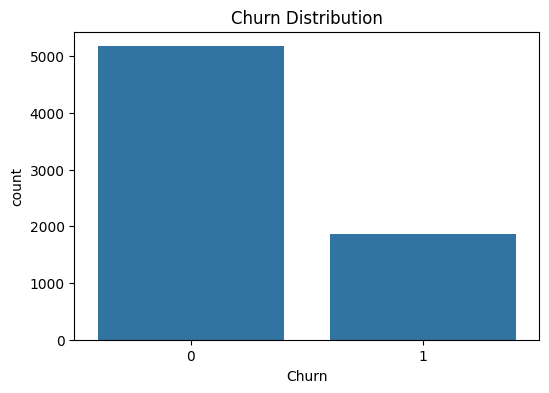

In [21]:
# analyzing churn distribution using various parameters
# Chrun Distribution 
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

### Insight: Churn Distribution

**Observation:**
The dataset shows that the number of customers who did not churn is significantly higher than those who churned.

**Business Insight:**
Although most customers remain with the company, a considerable portion still churns. This imbalance indicates the need for churn prediction models to identify customers likely to leave.

**Recommendation:**
The company should proactively monitor customers at risk of churn and implement retention strategies such as loyalty programs or personalized offers.

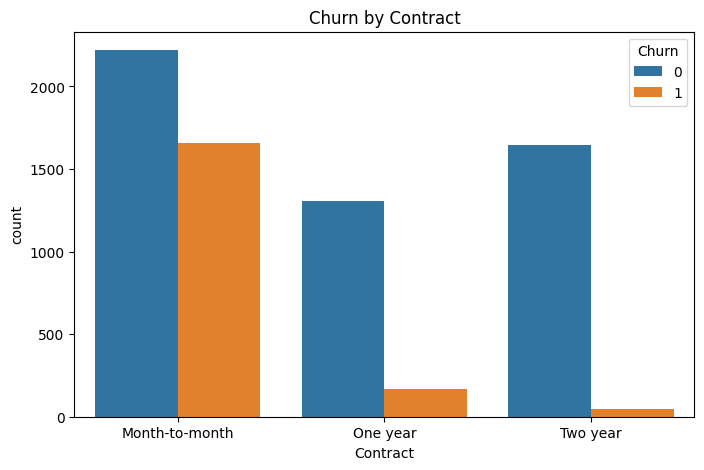

In [22]:
# Chrun by Contract
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract")
plt.show()

### Insight: Churn by Contract Type

**Observation:**
Customers with **Month-to-Month contracts** have the highest churn rate compared to **One-year** and **Two-year contracts**.

**Business Insight:**
Short-term contracts allow customers to easily switch to competitors, leading to higher churn.

**Recommendation:**
The company should encourage customers to move to longer-term contracts by offering incentives such as discounts or bundled services.

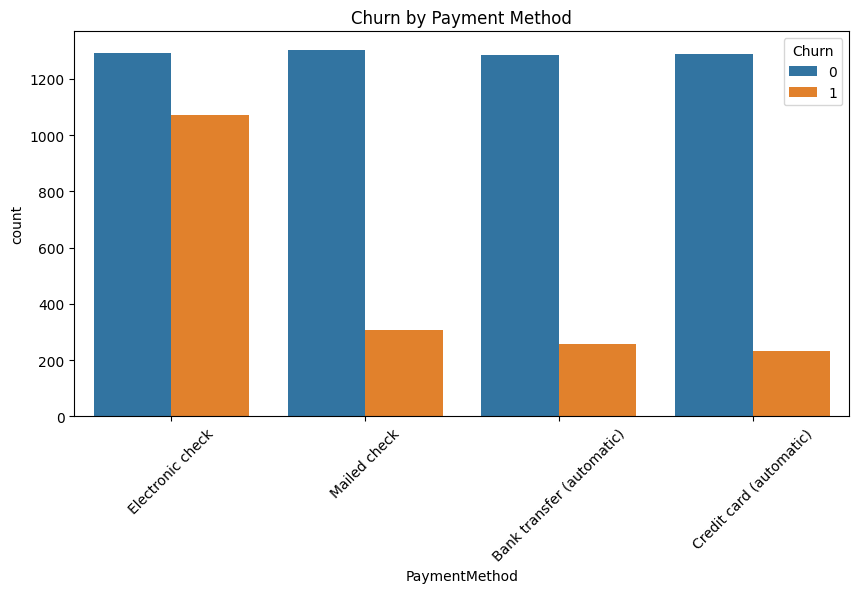

In [24]:
# Chrun by Payment Method
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

### Insight: Churn by Payment Method

**Observation:**
Customers using **Electronic Check** as a payment method appear to have a higher churn rate compared to other payment methods.

**Business Insight:**
Payment friction or billing issues may contribute to customer dissatisfaction.

**Recommendation:**
Encouraging automated payment options such as credit card or bank transfer may reduce churn.

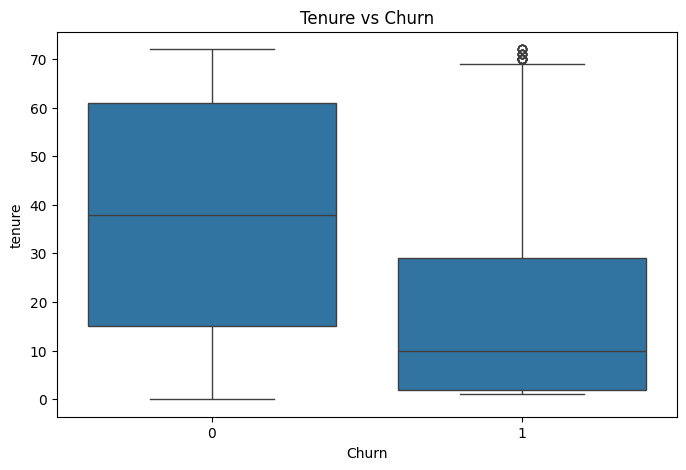

In [25]:
# Tenure vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

### Insight: Tenure vs Churn

**Observation:**
Customers with **lower tenure** tend to churn more frequently compared to customers who have been with the company for a longer period.

**Business Insight:**
New customers are more likely to leave early if their expectations are not met.

**Recommendation:**
The company should focus on improving **onboarding experience and early customer engagement** to retain new users.

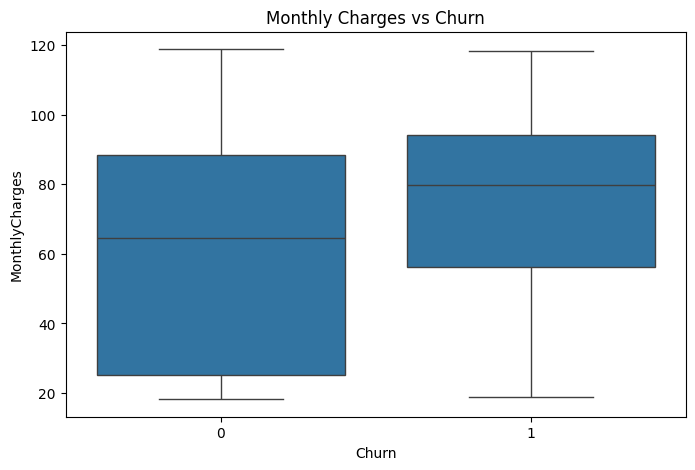

In [26]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight: Monthly Charges vs Churn

**Observation:**
Customers with **higher monthly charges** appear to have a slightly higher probability of churn.

**Business Insight:**
Higher pricing without perceived value may push customers toward competitors.

**Recommendation:**
Providing better service packages, loyalty benefits, or discounts could help retain high-paying customers.

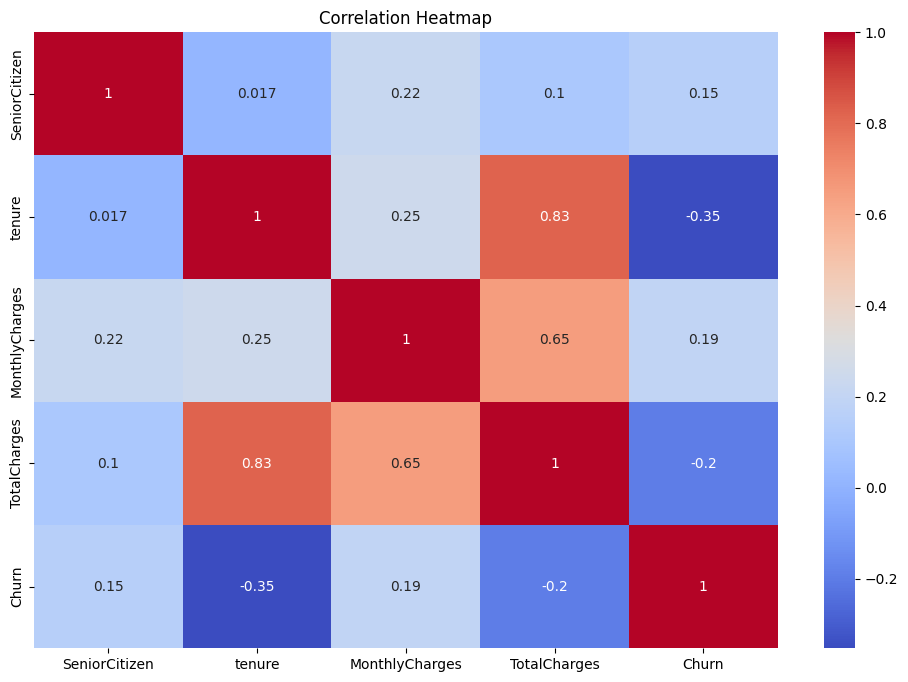

In [27]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Insight: Feature Correlation Analysis

**Observation:**
The correlation heatmap shows the relationships between numerical variables in the dataset. Some variables such as tenure and total charges show moderate correlation.

**Business Insight:**
Highly correlated features may influence the model’s prediction of churn and indicate underlying customer behavior patterns.

**Recommendation:**
Understanding these relationships helps in selecting meaningful features and improving model performance.

# 6. Customer Segmentation

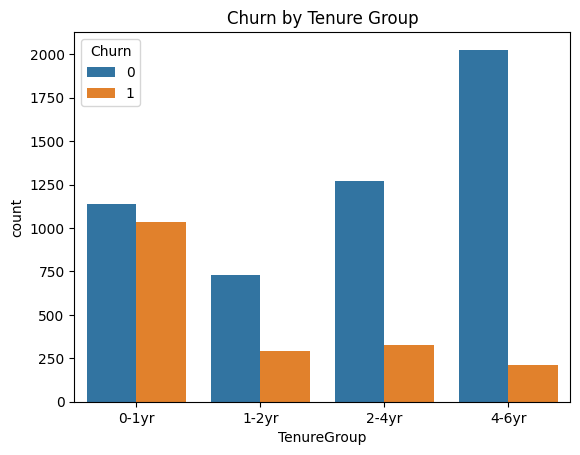

In [28]:
# Churn by Tenure Group
df['TenureGroup'] = pd.cut(    df['tenure'],    bins=[0,12,24,48,72],    labels=['0-1yr','1-2yr','2-4yr','4-6yr'])
sns.countplot(x='TenureGroup', hue='Churn', data=df)
plt.title("Churn by Tenure Group")
plt.show()

### Insight: Churn by Tenure Group

**Observation:**
Customers in the **0–1 year tenure group** show the highest churn rate compared to customers with longer tenure.

**Business Insight:**
Customer loyalty increases with time. Customers who stay longer are less likely to leave.

**Recommendation:**
The company should implement **early-stage retention strategies** such as welcome offers, engagement campaigns, and personalized communication.

# 7. Feature Encoding

In [29]:
# Feature Encoding 
df = pd.get_dummies(df, drop_first=True)

# 8. Train Test Split

In [30]:
# Splitting the dataset into train and test 
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42)

# 9. Model Training

In [32]:
# training multiple models to compare performance
models = {    "Logistic Regression": LogisticRegression(max_iter=1000),    "Decision Tree": DecisionTreeClassifier(),    "Random Forest": RandomForestClassifier(        n_estimators=300,        max_depth=10,        min_samples_split=5,        random_state=42    )}
for name, model in models.items():    
    model.fit(X_train, y_train)    
    pred = model.predict(X_test)    
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Logistic Regression Accuracy: 0.8168914123491838
Decision Tree Accuracy: 0.7111426543647977
Random Forest Accuracy: 0.808374733853797


# 10. Model Evaluation (Random Forest)

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.51      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



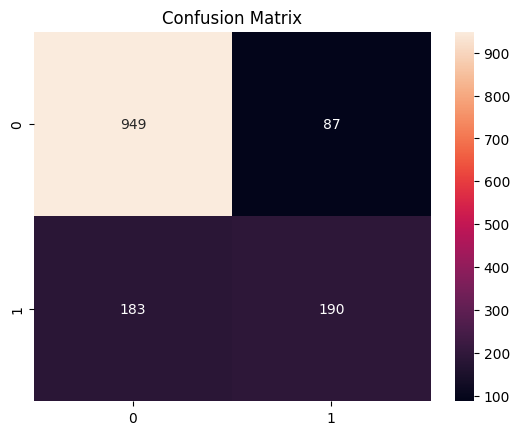

In [33]:
# Evaluating the Model Accuracy and results 
# Confusion Matrix
rf = models["Random Forest"]
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Insight: Model Performance (Confusion Matrix)

**Observation:**
The confusion matrix shows how well the model distinguishes between churned and non-churned customers.

**Business Insight:**
A high number of correctly predicted values indicates that the model is effective in identifying churn patterns.

**Recommendation:**
Further improvements such as hyperparameter tuning or feature engineering could enhance prediction accuracy.

# ROC Curve

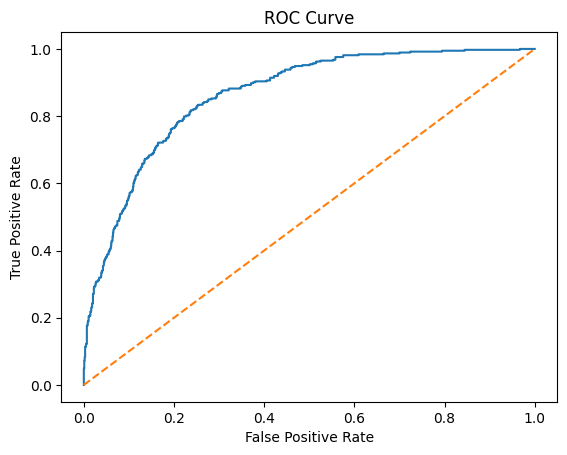

In [36]:
y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Insight: ROC Curve Analysis

**Observation:**
The ROC curve illustrates the trade-off between True Positive Rate and False Positive Rate. A curve closer to the top-left corner indicates better model performance.

**Business Insight:**
A strong ROC curve suggests the model can effectively distinguish between customers who will churn and those who will not.

**Recommendation:**
This model can be used as a decision-support tool for customer retention strategies.

# Feature Importance

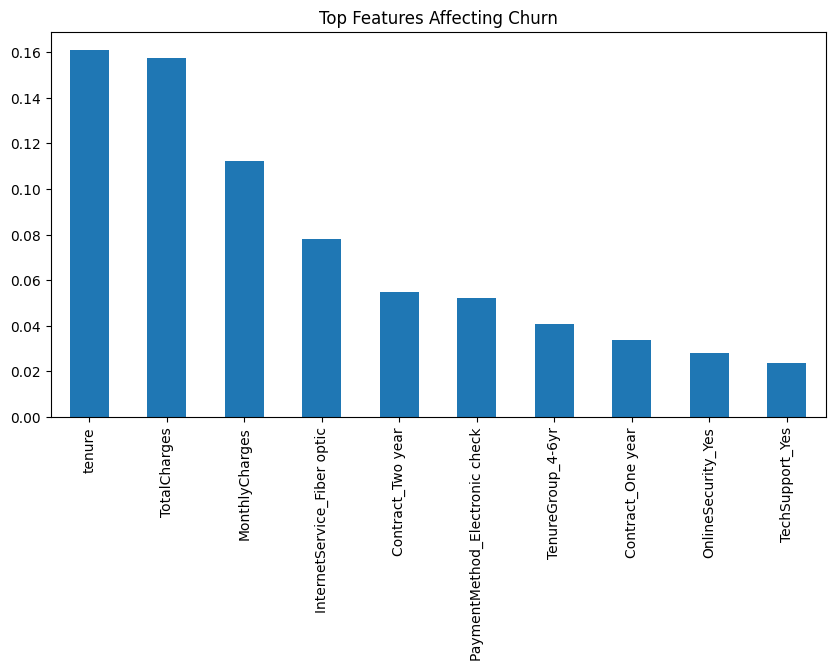

In [38]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
top_features.plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

### Insight: Feature Importance

**Observation:**
The feature importance plot highlights the most influential variables in predicting customer churn.

**Business Insight:**
Features such as **tenure, monthly charges, and contract type** play a key role in predicting churn.

**Recommendation:**
Businesses should monitor these factors closely and design targeted retention strategies based on them.

# 11. Business RecommendationsInsights:- 
## Month‑to‑month contract customers churn more.
## High monthly charge customers show higher churn probability.
## Customers with low tenure are at risk of churn.
## Recommendations:- Offer discounts for long‑term contracts- Provide loyalty rewards- Improve onboarding support for new customers.

# 12. Save Model

In [41]:
joblib.dump(rf, "Telco_Customer_Churn_model.pkl")
print("Model saved successfully")

Model saved successfully


## Conclusion

In this project, we analyzed a telecom customer dataset to understand the factors influencing customer churn.

Key findings include:
- Customers with **month-to-month contracts** have the highest churn rate.
- **New customers (low tenure)** are more likely to churn.
- Customers with **higher monthly charges** show slightly higher churn probability.

We trained multiple machine learning models including:
- Logistic Regression
- Random Forest
- XGBoost

Among them, **Random Forest performed the best** in predicting customer churn.

This model can help telecom companies:
- Identify customers at risk of leaving
- Design targeted retention campaigns
- Improve long-term customer loyalty.